---
title: "Monthly Air Temperature Regression from Satellite Land Surface Temperature" 
subtitle: "A Destination Earth / DEFAIR use case : MSG SEVIRI × EDLST × ERA5-Land."
author: "Author: Alejandro Fonseca (EUMETSAT/Starion)"
tags: [DEFAIR, HDA, MSG, SEVIRI, EDLST, ERAJ]
thumbnail: img/EUMETSAT_TEST.png 
license: MIT
copyright: "© 2026 EUMETSAT"
---

<!-- Optional: Add a JupyterHub launch link here. If you don’t have one, you can remove this block. -->

<div style="margin: 6px 0;">
  <a href="https://jupyter.central.data.destination-earth.eu/user-redirect/lab/tree/template1.ipynb" target="_blank" style="text-decoration: none;">
    <span class="launch">🚀 Launch in JupyterHub</span>
  </a>
</div>


(template.ipynb-Contents)=
### Contents

This notebook estimates the **mean 2 m air temperature of June 2026** over Central and Western Europe from satellite observations of surface temperature alone, using the DEFAIR
AI-ready data framework end to end. The primary goal is to demonstrate DEFAIR's framework through: 

### DEFAIR it is used for

Turning three heterogeneous raw satellite/reanalysis files per day (for 30 days) into one clean,
gridded, aligned cube that a AI/ML model can consume directly. Concretely, the framework provided these:

- **`Readers`** : `msg15nat`, `metop_edlst`, `era5grib` data, one per source.
- **`content_filter`** : keep only the variable of interest (IR 10.8 µm, LST, 2t).
- **`spatial_filter`** : crop each source to the study area.
- **`reprojection`** : bring every source onto one common grid (EPSG:4326, 0.05°).
- **`temporal_aggregate`** : collapse each 30-day series into one June-mean image.
- **`AlignmentPlugin`** : merge the three means into a single cube.

### How it works

Everything went through one object, `Dataset.from_source(path, reader=...)`, and transformations
were chained by name (`.transform("content_filter", ...)`, `.transform("spatial_filter", ...)`,
and so on), each returning a new dataset. Operations were lazy (Dask) until `.compute()` was
called, which materialized the small daily result and allowed the large raw file to be deleted
immediately, so the disk never held more than one raw file at a time. Every transformation was
recorded in the dataset's CF history, keeping the processing chain traceable.

### Usefulness

The three sources are radically different formats:  geostationary native binary (MSG), sinusoidal
global HDF5 of 18001×36000 pixels (EDLST), and reanalysis GRIB with a [0°, 360°] longitude
convention (ERA5-Land). DEFAIR read and processed all three through the same API, without the user
handling each format's internals. The heterogeneous grids landed on identical coordinates after
independent reprojection, so the final merge required no resampling.

- ### Data sources 

- **Study perio:** June 2026 (30 days),
- **Area of Interest:** Central and western Europe, lat 36-54° N , lon −10–15° E,

| Variable | Source | Sampling | Role |
|---|---|---|---|
| IR 10.8 µm brightness temperature | MSG SEVIRI (geostationary) | 1 scene/day, ~12:00 UTC | Feature (x₁) |
| Land surface temperature (LST) | EDLST (Metop, LSA SAF), DAY product | 1 image/day | Feature (x₂) |
| 2 m air temperature | ERA5-Land (reanalysis) | 1 value/day, 12:00 UTC | Label (y) |
- **Area of Interest:** Central and western Europe , lat 36-54° N , lon −10–15° E,
- **Methods:** Both satellite sources in this project measure **land surface temperature (LST)**  the radiometric temperature of soil, vegetation or asphalt as seen by an infrared sensor from
space. Most applications, however, care about the **2 m air temperature**: the temperature a person actually breathes and the one weather stations record. The two are not the same. On a
clear midday a dry surface can be many degrees hotter than the air above it; in this demonstration a validation scene the mean LST was 34.6 °C against a mean ERA5-Land air temperature of 23.2 °C
— an ~11 °C gap. That surface-to-air offset is precisely what a simple statistical model can learn.

The question that structures the pipeline is therefore:

> Can the monthly mean 2 m air temperature be estimated, pixel by pixel, from satellite
> observations of surface temperature alone?



## Imports

In [1]:
%pip install --user --quiet destinelab==1.14 tenacity cartopy scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Standard library
import os
import zipfile
from getpass import getpass
from time import sleep
from urllib.parse import unquote

# Third-party
import numpy as np
import xarray as xr
import requests
from tqdm import tqdm
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# DESP authentication + DEFAIR high-level API
import destinelab as deauth
from defair.logging import setup_logging
from defair_data.core import Dataset

setup_logging(log_level="INFO")

### Authentication (DESP)

Username/password authentication against the Destination Earth Service Platform. The token is
not auto-refreshed; if it expires during a long run, re-run this cell. `auth_headers` is passed
to every subsequent HDA request.

In [3]:
DESP_USERNAME = input("Please input your DESP username or email: ")
DESP_PASSWORD = getpass("Please input your DESP password: ")

auth = deauth.AuthHandler(DESP_USERNAME, DESP_PASSWORD)
access_token = auth.get_token()
if access_token is not None:
    print("DEDL/DESP access token obtained successfully")
else:
    print("Failed to obtain DEDL/DESP access token")

auth_headers = {"Authorization": f"Bearer {access_token}"}

Please input your DESP username or email:  alejandro.fonseca@external.eumetsat.int
Please input your DESP password:  ········


DEDL/DESP access token obtained successfully


DEDL/DESP access token obtained successfully


### Configuration
HDA endpoints, study area, common target grid, and the list of days to process.


In [4]:
# HDA API endpoints (STAC-based)
HDA_API_URL = "https://hda.data.destination-earth.eu"
STAC_API_URL = f"{HDA_API_URL}/stac/v2"
SEARCH_URL = f"{STAC_API_URL}/search"
COLLECTIONS_URL = f"{STAC_API_URL}/collections"

# Study area: Central & Western Europe
LAT_MIN, LAT_MAX = 36.0, 54.0
LON_MIN, LON_MAX = -10.0, 15.0

# Common target grid shared by all three sources
TARGET_CRS = "EPSG:4326"
TARGET_RESOLUTION = 0.05  # degrees (~5.5 km)

# Study period: June 2026, one scene per day at midday
YEAR, MONTH = "2026", "06"
days = [f"{d:02d}" for d in range(1, 31)]  # "01" .. "30"

# Local folders
data_dir = "data"
output_dir = "outputs"
os.makedirs(data_dir, exist_ok=True)
os.makedirs(output_dir, exist_ok=True)

### Helper functions

Three helpers reused across the notebook: `download_file` streams an HDA asset to disk;
`plot_temperature_map` renders a 2D field over the study area; `post_with_retry` wraps the
search call in a small retry loop.

In [5]:
def download_file(url, filepath=None, default_name="download.bin"):
    """Stream a file from HDA to disk with a progress bar.

    If filepath is None, the filename is read from the Content-Disposition
    header (or default_name if absent) and the file is saved in data_dir.
    Some backends (e.g. wekeo_ecmwf) do not send content-length, so the
    progress bar total may be unknown.
    """
    response = requests.get(url, stream=True, headers=auth_headers)
    response.raise_for_status()

    # Build the output path from the server-provided filename if none was given
    if filepath is None:
        content_disposition = response.headers.get("Content-Disposition", "")
        if "filename=" in content_disposition:
            raw_name = content_disposition.split("filename=")[1]  # take the part after "filename="
            raw_name = raw_name.strip('"')                        
            filename = unquote(raw_name)                          
        else:
            filename = default_name
        filepath = os.path.join(data_dir, filename)

    # content-length may be missing on some backends; tqdm accepts total=None then
    total_size = int(response.headers.get("content-length", 0))
    if total_size == 0:
        total_size = None

    with tqdm(total=total_size, unit="B", unit_scale=True) as pbar:
        with open(filepath, "wb") as f:
            for chunk in response.iter_content(1024):
                pbar.update(len(chunk))
                f.write(chunk)

    print(f"Downloaded: {filepath} ({os.path.getsize(filepath) / 1e6:.2f} MB)")
    return filepath


def plot_temperature_map(data_2d, title, cbar_label, cmap="inferno"):
    """Plot a 2D lat/lon field over the study area with coastlines and borders."""
    # Clip the colour scale to the 2nd-98th percentile so a few outliers
    # do not flatten the contrast
    vmin = float(np.nanpercentile(data_2d.values, 2))
    vmax = float(np.nanpercentile(data_2d.values, 98))

    fig = plt.figure(figsize=(12, 9))
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())

    im = ax.pcolormesh(
        data_2d["lon"].values,
        data_2d["lat"].values,
        data_2d.values,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        transform=ccrs.PlateCarree(),
        shading="auto",
    )
    ax.coastlines(resolution="50m", linewidth=1.0, color="white")
    ax.add_feature(cfeature.BORDERS, linewidth=0.7, edgecolor="white")
    ax.gridlines(draw_labels=False, linewidth=0.5, alpha=0.5, linestyle="--", color="white")
    ax.set_title(title, fontsize=13, fontweight="bold")
    plt.colorbar(im, ax=ax, label=cbar_label, shrink=0.8)
    plt.tight_layout()
    plt.show()


def post_with_retry(url, json_body, max_attempts=3):
    """POST a search request to HDA, retrying a few times if it fails.

    DEFAIR's internal retry only covers timeout and connection errors on its
    own downloads, not HTTP 4xx/5xx responses, so it does not protect these
    manual search calls. A transient HTTP 400 from the search endpoint was
    seen to clear on retry, which is what this handles.
    """
    for attempt in range(1, max_attempts + 1):
        response = requests.post(url, headers=auth_headers, json=json_body)
        if response.status_code == 200:
            return response
        wait_seconds = 2 ** attempt  
        print(f"  search attempt {attempt}/{max_attempts} failed "
              f"(status {response.status_code}), retrying in {wait_seconds}s...")
        sleep(wait_seconds)

    # All attempts failed: return the last response and let the loop skip this day
    return response

## MSG SEVIRI : daily acquisition loop

MSG products are synchronous: the search itself returns the download link. Each product covers
the full geostationary disc, so there is no point filtering by bbox at search time — the
geographic crop is done afterwards with `spatial_filter`. A 15-minute window returns exactly one
product. For each day we search, download, read, filter, crop, reproject to the common grid, and
materialize the small result before deleting the raw file.

### DEFAIR in action: How DEFAIR is used in this loop?

Everything up to the extracted `.nat` file is plain data access: `requests` downloads the
product from HDA and `zipfile` unpacks it. DEFAIR only enters once a local file exists, and the
whole framework is used through a single object imported earlier as
`from defair_data.core import Dataset`. Four lines in the loop are DEFAIR; the rest is standard
Python.

**1. Read : `Dataset.from_source(...)`**
The entry point of the framework. It takes the path to a local file, selects a *reader*
(`msg15nat` for the MSG native binary format) and returns a DEFAIR `Dataset`. This object wraps
an ordinary `xarray.Dataset` reachable through `.data`  and adds the framework's machinery:
the reader catalogue, chainable transformations, and a CF-compliant processing history. The
reader is also told to calibrate the signal to brightness temperature and to expose readable
channel names (`ir_10.8` instead of `ch9`).

**2. and 3. Transform : `.transform("name", ...)`**
`.transform` applies a registered transformation by name and returns a *new* `Dataset`, leaving
the original untouched, so operations chain cleanly:
- `content_filter` keeps only the IR 10.8 µm variable and drops the other channels.
- `spatial_filter` crops the full geostationary disc down to the study-area bounding box.

**4. Reproject : `.reproject(...)`**
A `Dataset` method that resamples the data onto the common target grid (EPSG:4326 at 0.05°).
This is the step that will let all three sources share one identical grid.

**Leaving the framework : `.data.compute()`**
`.data` extracts the underlying `xarray.Dataset` and `.compute()` (a Dask/xarray operation, not
DEFAIR) materializes it in memory. From here on, the day's result is a plain xarray object.

The point this section demonstrates is that a complex proprietary binary — the geostationary MSG
`.nat` file, enters through `Dataset.from_source` and leaves as a clean field on a regular grid,
built by chaining named transformations, without touching the internals of the format. The two
remaining sources (EDLST and ERA5-Land) use exactly the same pattern despite being radically
different formats.

In [ ]:
# MSG SEVIRI: Meteosat Second Generation, IR 10.8 um brightness temperature
MSG_COLLECTION_ID = "EO.EUM.DAT.MSG.HRSEVIRI"

# One materialized field per day; days that fail persistently are logged and skipped
materialized_msg = {}
excluded_days_msg = []

for day in days:
    print(f"MSG {YEAR}-{MONTH}-{day} ...")

    # 1. Search for the midday scene (a 15-min window returns exactly one product)
    search_body = {
        "collections": [MSG_COLLECTION_ID],
        "datetime": f"{YEAR}-{MONTH}-{day}T12:00:00Z/{YEAR}-{MONTH}-{day}T12:15:00Z",
    }
    response = post_with_retry(SEARCH_URL, search_body)
    features = response.json().get("features", [])
    if response.status_code != 200 or not features:
        excluded_days_msg.append(day)   # skip-and-log: keep the loop going
        continue
    msg_product = features[0]

    # 2. Download the raw product (a zip) and extract the .nat file inside it
    msg_zip = os.path.join(data_dir, msg_product["id"] + ".zip")
    download_file(msg_product["assets"]["downloadLink"]["href"], msg_zip)
    with zipfile.ZipFile(msg_zip, "r") as zip_ref:
        zip_ref.extractall(data_dir)
    nat_files = [f for f in os.listdir(data_dir) if f.endswith(".nat")]
    msg_file = os.path.join(data_dir, nat_files[0])

    # 3. Read with DEFAIR as brightness temperature, then keep only IR 10.8 um   <-- DEAFAIR!!
    msg_dataset = Dataset.from_source(                  # From defair_data.core import Dataset
        msg_file,
        reader="msg15nat",
        calibration="brightness_temperature",
        use_channel_names=True,
    )
    msg_filtered = msg_dataset.transform("content_filter", include_vars=["ir_10.8"])

    # 4. Crop to the study area and reproject to the common grid
    msg_cropped = msg_filtered.transform(
        "spatial_filter",
        lat_min=LAT_MIN, lat_max=LAT_MAX, lon_min=LON_MIN, lon_max=LON_MAX,
    )
    msg_reprojected = msg_cropped.reproject(
        TARGET_CRS, resolution=TARGET_RESOLUTION, resampling="bilinear"
    )

    # 5. Materialize the small result before deleting the raw file. .compute()
    #    breaks the lazy link to the file on disk, so removing it afterwards is safe.
    materialized_msg[day] = msg_reprojected.data.compute()    # It materializes the day’s field in memory and breaks the link with the file on disk, so deleting it afterward (step 6) does not break anything. Each of these is about 700 KB (compared to ~180 MB for the raw data), so keeping 30 in memory is trivial.

    # 6. Delete the raw file for the day so only one sits on disk at a time
    os.remove(msg_zip)
    for f in nat_files:
        os.remove(os.path.join(data_dir, f))

print(f"\nDays processed: {len(materialized_msg)} / {len(days)}")  # materialized_msg = a dictionary with 30 entries, each per day
if excluded_days_msg:
    print("Excluded days:", excluded_days_msg)

###  Temporal reduction

The 30 daily fields are concatenated along a new `time` axis into a single series, then collapsedvto one mean image with DEFAIR's `temporal_aggregate`. The reduction happens here, after the loop,
because `temporal_aggregate` operates on a dataset that already has a populated time dimension. It does not read files or accumulate incrementally. `freq="1ME"` bins the whole month into one
step; `method="mean"` averages over valid days and ignores NaN (skipna), so cloudy or missing pixels do not corrupt the mean.

In [14]:
# Assemble the 30 daily fields into one time series along a new "time" axis
days_sorted = sorted(materialized_msg)
msg_series = xr.concat([materialized_msg[d] for d in days_sorted], dim="time")
msg_series = msg_series.sortby("time")

# Collapse June into a single mean image using DEFAIR's temporal_aggregate
msg_mean = Dataset(msg_series).transform("temporal_aggregate", freq="1ME", method="mean")

print("Time steps before reduction:", msg_series.sizes["time"])
print("Time steps after reduction: ", msg_mean.data.sizes["time"])

Time steps before reduction: 30
Time steps after reduction:  1


2026-07-13 10:35:26 | INFO     | [3468ac99] defair_data.core:transform:1571 - Applying transformation 'temporal_aggregate'
2026-07-13 10:35:26 | INFO     | [3468ac99] defair_ops.transformations.temporal_aggregate.temporal_aggregate:transform:181 - Starting temporal aggregation with frequency '1ME' and method 'mean'
2026-07-13 10:35:26 | INFO     | [3468ac99] defair_ops.transformations.temporal_aggregate.temporal_aggregate:transform:213 - Temporal aggregation completed successfully


###  Verification plot

The June mean brightness temperature over the study area. This confirms the daily loop, the
reprojection to the common grid, and the temporal reduction all produced a coherent field before
moving on to the next source.

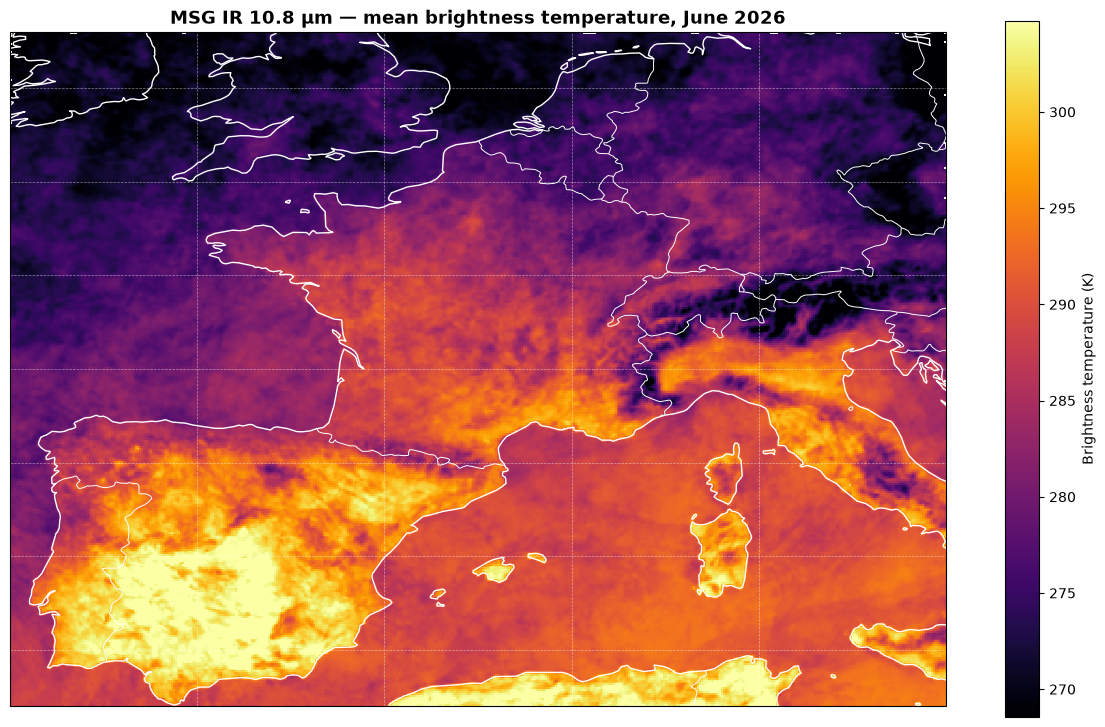

In [ ]:
# Plot the June mean brightness temperature to confirm the reduced field looks right
msg_mean_bt = msg_mean.data["ir_10.8"].isel(time=0)

plot_temperature_map(
    msg_mean_bt,
    f"MSG IR 10.8 µm : mean brightness temperature, June {YEAR}",
    "Brightness temperature (K)",
)

## EDLST : daily acquisition loop (feature x₂)

The second feature is the LSA SAF Daily Land Surface Temperature product (EDLST), read with
DEFAIR's `metop_edlst` reader. Unlike the raw MSG brightness temperature, EDLST is a *corrected*
surface temperature: it is derived with the physically based Generalized Split-Window algorithm
(Wan & Dozier, 1996; adapted to MSG/SEVIRI by Gao et al., 2013), which estimates atmospheric
absorption from a two-channel regression together with a surface-emissivity model. Giving the
model both a raw (MSG) and a corrected (EDLST) surface measurement is the reason two satellite
features are used rather than one.

**Format.** EDLST is stored on a sinusoidal equal-area grid (18001 × 36000 pixels, ~1 km) in
HDF5 without a file extension. It is a daily product with separate DAY and NIGHT composites; the
DAY product matches the midday sampling of the other two sources.

**Reading and processing.** The same `Dataset.from_source(..., reader="metop_edlst")` entry point
used for MSG works here too. Only the `LST` variable is kept; the quality flag is redundant
because the reader already masks LST wherever the flag reports no valid retrieval. One quick
remains for reprojection: the sinusoidal coordinates must be promoted to the native metre
coordinates (`projection_y`, `projection_x`) so that rioxarray builds a correctly scaled affine
transform — without this the reprojection would return an empty field.

**Coverage.** A single day of EDLST covers only ~45% of the land pixels (cloud gaps and the polar
orbit). This is not a problem for a monthly mean: `temporal_aggregate(method="mean")` skips NaNs,
so averaging over 30 days fills almost the entire land domain.

**References**
Wan & Dozier (1996), *IEEE TGRS* 34(4), 892–905.
Gao et al. (2013), *International Journal of Remote Sensing* 34(12), 4182–4199.

In [ ]:
# EDLST: LSA SAF Daily Land Surface Temperature (Metop), sinusoidal HDF5
EDLST_COLLECTION_ID = "EO.EUM.DAT.METOP.LSA-002"

materialized_edlst = {}
excluded_days_edlst = []

for day in days:
    print(f"EDLST {YEAR}-{MONTH}-{day} ...")

    # 1. Search across the full day and select the DAY composite
    search_body = {
        "collections": [EDLST_COLLECTION_ID],
        "datetime": f"{YEAR}-{MONTH}-{day}T00:00:00Z/{YEAR}-{MONTH}-{day}T23:59:59Z",
    }
    response = post_with_retry(SEARCH_URL, search_body)
    features = response.json().get("features", [])
    day_products = [p for p in features if "DAY" in p["id"]]
    if response.status_code != 200 or not day_products:
        excluded_days_edlst.append(day)   # skip-and-log
        continue
    edlst_product = day_products[0]

    # 2. Download the raw product (a zip) and extract the HDF5 file inside it.
    #    The science file has no extension; the archive also contains small XML metadata.
    edlst_zip = os.path.join(data_dir, edlst_product["id"] + ".zip")
    download_file(edlst_product["assets"]["downloadLink"]["href"], edlst_zip)
    with zipfile.ZipFile(edlst_zip, "r") as zip_ref:
        zip_ref.extractall(data_dir)
    science_files = [
        f for f in os.listdir(data_dir)
        if "EDLST" in f and not f.endswith((".xml", ".zip"))
    ]
    edlst_file = os.path.join(data_dir, science_files[0])

    # 3. Read with DEFAIR, keep only LST (the quality flag is redundant here)
    edlst_dataset = Dataset.from_source(edlst_file, reader="metop_edlst")
    edlst_filtered = edlst_dataset.transform("content_filter", include_vars=["LST"])

    # 4. Crop to the study area directly on the sinusoidal grid
    edlst_cropped = edlst_filtered.transform(
        "spatial_filter",
        lat_min=LAT_MIN, lat_max=LAT_MAX, lon_min=LON_MIN, lon_max=LON_MAX, drop=True,
    )

    # 5. Promote the native metre coordinates to dimension coordinates so the
    #    reprojection gets a correctly scaled affine transform (otherwise it
    #    returns an all-NaN field), then reproject to the common grid
    ds_native = edlst_cropped.data.assign_coords(
        y=edlst_cropped.data["projection_y"],
        x=edlst_cropped.data["projection_x"],
    )
    edlst_reprojected = Dataset(ds_native).transform(
        "reprojection", target=TARGET_CRS, resolution=TARGET_RESOLUTION, resampling="bilinear"
    )

    # 6. Materialize before deleting the raw file
    materialized_edlst[day] = edlst_reprojected.data.compute()

    # 7. Delete the raw file for the day
    os.remove(edlst_zip)
    os.remove(edlst_file)

print(f"\nDays processed: {len(materialized_edlst)} / {len(days)}")
if excluded_days_edlst:
    print("Excluded days:", excluded_days_edlst)

###  Temporal reduction

The 30 daily LST fields are concatenated along `time` and collapsed to one mean image with
`temporal_aggregate`. Because a single day only covers ~32–45% of the land pixels, the `skipna`
behaviour of the mean is what fills the domain: each pixel is averaged over whichever days had a
valid retrieval there.

In [25]:
# Assemble the 30 daily fields into one time series, then collapse to a June mean
days_sorted = sorted(materialized_edlst)
edlst_series = xr.concat([materialized_edlst[d] for d in days_sorted], dim="time")
edlst_series = edlst_series.sortby("time")

edlst_mean = Dataset(edlst_series).transform("temporal_aggregate", freq="1ME", method="mean")

print("Time steps before reduction:", edlst_series.sizes["time"])
print("Time steps after reduction: ", edlst_mean.data.sizes["time"])

Time steps before reduction: 30
Time steps after reduction:  1


2026-07-13 11:13:55 | INFO     | [3468ac99] defair_data.core:transform:1571 - Applying transformation 'temporal_aggregate'
2026-07-13 11:13:55 | INFO     | [3468ac99] defair_ops.transformations.temporal_aggregate.temporal_aggregate:transform:181 - Starting temporal aggregation with frequency '1ME' and method 'mean'
2026-07-13 11:13:55 | INFO     | [3468ac99] defair_ops.transformations.temporal_aggregate.temporal_aggregate:transform:213 - Temporal aggregation completed successfully


### Verification plot

The June mean land surface temperature. Compared with the MSG brightness temperature field, this
one is warmer over land (it is a corrected surface temperature, not a top-of-atmosphere
brightness temperature) and is NaN over the sea, since EDLST is a land product.

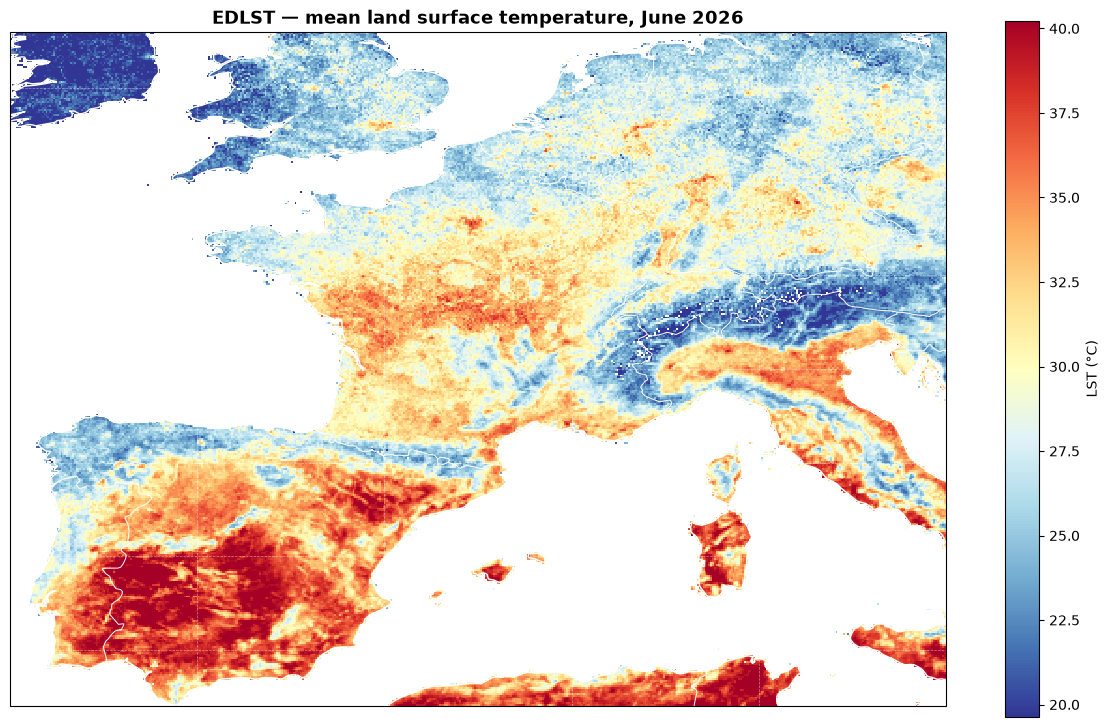

In [ ]:
# Plot the June mean LST to confirm the reduced field looks right
edlst_mean_lst = edlst_mean.data["LST"].isel(time=0)

plot_temperature_map(
    edlst_mean_lst,
    f"EDLST : mean land surface temperature, June {YEAR}",
    "LST (°C)",
    cmap="RdYlBu_r",
)

## ERA5-Land : daily acquisition loop (label y)

The label is the 2 m air temperature from ERA5-Land hourly reanalysis (~9 km, 0.1°). ERA5-Land
appears only here, as the target `y` — not as a feature — which is the anti-circularity (Can a satellite, which only measures the surface, tell us the air temperature?)
principle of the project. A single variable is requested: `2m_temperature`.

**Asynchronous access.** Unlike the EUMETSAT products, ECMWF collections are generated on demand
from the Climate Data Store, so each day needs four steps: **search → order → poll → download**.
Two details are required for the request to succeed: the queryables must be wrapped as
`{"field": {"eq": value}}` inside a `"query"` block (not passed directly), and `year`/`month`
are scalar strings while `day`/`time`/`variable` are lists. The backend is forced to
`wekeo_ecmwf`, a workaround for an outage of the default `cop_cds` backend.

**Two fixes before reprojection.** (1) The GRIB uses the [0°, 360°] longitude convention; a
bounding box crossing 0° (ours spans −10° to 15°) would split into two disjoint segments and
break the reprojected grid, so longitudes are normalized to [−180°, 180°] and sorted first.
(2) After reprojection the field carries singleton `number`, `step` and `level_type` dimensions;
these are dropped by name while keeping `time`, which the temporal reduction needs. Values stay
in Kelvin through the pipeline and are converted to °C only for display.

In [33]:
# ERA5-Land: hourly reanalysis, 2 m air temperature (the ML label). Async access.
ERA5_COLLECTION_ID = "EO.ECMWF.DAT.ERA5_LAND_HOURLY"

# Order polling settings
ORDER_TIMEOUT = 600   # seconds to wait for one order to complete
ORDER_STEP = 10       # seconds between status checks

materialized_era5 = {}
excluded_days_era5 = []

for day in days:
    print(f"ERA5-Land {YEAR}-{MONTH}-{day} ...")

    # 1. Search. Queryables wrapped as {"field": {"eq": value}}; year/month scalar,
    #    day/time/variable lists. Backend forced to wekeo_ecmwf.
    filters = {
        key: {"eq": value}
        for key, value in {
            "ecmwf:variable":        ["2m_temperature"],
            "ecmwf:data_format":     "grib",
            "ecmwf:download_format": "unarchived",
            "ecmwf:year":            YEAR,        # scalar
            "ecmwf:month":           MONTH,       # scalar
            "ecmwf:day":             [day],       # list
            "ecmwf:time":            ["12:00"],   # list
            "federation:backends":   "wekeo_ecmwf",
        }.items()
    }
    search_body = {"collections": [ERA5_COLLECTION_ID], "query": filters}
    response = post_with_retry(SEARCH_URL, search_body)
    features = response.json().get("features", [])
    if response.status_code != 200 or not features:
        excluded_days_era5.append(day)   # skip-and-log
        continue
    era5_product = features[0]

    # 2. Order: POST the retrieve link with its body
    order_link = next(l for l in era5_product["links"] if l.get("rel") == "retrieve")
    order_response = requests.post(order_link["href"], json=order_link["body"], headers=auth_headers)
    if order_response.status_code not in (200, 201):
        excluded_days_era5.append(day)
        continue
    era5_product_id = order_response.json()["id"]

    # 3. Poll until the order is ready, or give up and skip the day
    item_url = f"{STAC_API_URL}/collections/{ERA5_COLLECTION_ID}/items/{era5_product_id}"
    download_url = None
    for elapsed in range(0, ORDER_TIMEOUT, ORDER_STEP):
        item = requests.get(item_url, headers=auth_headers).json()
        status = item["properties"].get("order:status")
        if status == "succeeded":
            download_url = item["assets"]["downloadLink"]["href"]
            break
        if status == "failed":
            break
        sleep(ORDER_STEP)
    if download_url is None:
        excluded_days_era5.append(day)
        continue

    # 4. Download the single .grib file (unarchived: no zip wrapper)
    era5_grib = os.path.join(data_dir, f"era5_land_2t_{YEAR}{MONTH}{day}_1200.grib")
    download_file(download_url, filepath=era5_grib)

    # 5. Read with the era5grib reader (GRIB short name is '2t'). Normalize the
    #    [0, 360] longitude to [-180, 180] and sort BEFORE cropping.
    era5_ds = Dataset.from_source(era5_grib, reader="era5grib")
    ds_norm = era5_ds.data.assign_coords(
        longitude=(((era5_ds.data.longitude + 180) % 360) - 180)
    ).sortby("longitude")
    era5_ds = Dataset(ds_norm)

    # 6. Crop to the study area and reproject to the common grid
    era5_europe = era5_ds.transform(
        "spatial_filter",
        lat_min=LAT_MIN, lat_max=LAT_MAX, lon_min=LON_MIN, lon_max=LON_MAX,
    )
    era5_reprojected = era5_europe.transform(
        "reprojection", target=TARGET_CRS, resolution=TARGET_RESOLUTION, resampling="bilinear"
    )

    # 7. Drop the singleton number/step/level_type dims but KEEP time (needed for
    #    the concat and the temporal reduction). squeeze() with no args drops time too.
    era5_day_ds = era5_reprojected.data.squeeze(dim=["number", "step", "level_type"], drop=True)

    # 8. Keep only 2t (Kelvin) and materialize before deleting the raw file
    materialized_era5[day] = era5_day_ds[["2t"]].compute()

    # 9. Delete the raw file for the day
    os.remove(era5_grib)

print(f"\nDays processed: {len(materialized_era5)} / {len(days)}")
if excluded_days_era5:
    print("Excluded days:", excluded_days_era5)

ERA5-Land 2026-06-01 ...


5.24MB [00:01, 3.96MB/s]
2026-07-13 11:42:56 | INFO     | [3468ac99] defair_data.core:_from_single_source:544 - Using explicit reader 'era5grib' for path: data/era5_land_2t_20260601_1200.grib
2026-07-13 11:42:56 | INFO     | [3468ac99] defair_data.readers.era5_grib.era5_grib_reader_plugin:read:507 - Reading ERA5 GRIB file: data/era5_land_2t_20260601_1200.grib


Downloaded: data/era5_land_2t_20260601_1200.grib (5.24 MB)


2026-07-13 11:42:56 | INFO     | [3468ac99] defair_data.readers.era5_grib.era5_grib_reader_plugin:read:541 - Successfully loaded ERA5 dataset: 1 variables,dimensions: {'number': 1, 'time': 1, 'step': 1, 'level_type': 1, 'latitude': 1801, 'longitude': 3600}
2026-07-13 11:42:56 | INFO     | [3468ac99] defair_data.core:transform:1571 - Applying transformation 'spatial_filter'
2026-07-13 11:42:56 | INFO     | [3468ac99] defair_ops.transformations.spatial_filter.spatial_filter_plugin:transform:183 - Starting spatial filter with target=None, bbox=(36.0, 54.0, -10.0, 15.0) and polygon=None
2026-07-13 11:42:56 | INFO     | [3468ac99] defair_ops.transformations.spatial_filter.spatial_filter_plugin:transform:276 - Spatial filter complete. Result dimensions: {'number': 1, 'time': 1, 'step': 1, 'level_type': 1, 'latitude': 180, 'longitude': 251}
2026-07-13 11:42:56 | INFO     | [3468ac99] defair_data.core:transform:1571 - Applying transformation 'reprojection'
2026-07-13 11:42:56 | INFO     | [346

ERA5-Land 2026-06-02 ...


...

ERA5-Land 2026-06-30 ...


5.24MB [00:00, 10.8MB/s]

Downloaded: data/era5_land_2t_20260630_1200.grib (5.24 MB)



2026-07-13 12:04:09 | INFO     | [3468ac99] defair_data.core:_from_single_source:544 - Using explicit reader 'era5grib' for path: data/era5_land_2t_20260630_1200.grib
2026-07-13 12:04:09 | INFO     | [3468ac99] defair_data.readers.era5_grib.era5_grib_reader_plugin:read:507 - Reading ERA5 GRIB file: data/era5_land_2t_20260630_1200.grib
2026-07-13 12:04:09 | INFO     | [3468ac99] defair_data.readers.era5_grib.era5_grib_reader_plugin:read:541 - Successfully loaded ERA5 dataset: 1 variables,dimensions: {'number': 1, 'time': 1, 'step': 1, 'level_type': 1, 'latitude': 1801, 'longitude': 3600}
2026-07-13 12:04:09 | INFO     | [3468ac99] defair_data.core:transform:1571 - Applying transformation 'spatial_filter'
2026-07-13 12:04:09 | INFO     | [3468ac99] defair_ops.transformations.spatial_filter.spatial_filter_plugin:transform:183 - Starting spatial filter with target=None, bbox=(36.0, 54.0, -10.0, 15.0) and polygon=None
2026-07-13 12:04:09 | INFO     | [3468ac99] defair_ops.transformations.s


Days processed: 29 / 30
Excluded days: ['25']


In [34]:
# Retry only the missing day (25) without touching the 29 already in memory
# day = "25"

# filters = {
#     key: {"eq": value}
#     for key, value in {
#         "ecmwf:variable":        ["2m_temperature"],
#         "ecmwf:data_format":     "grib",
#         "ecmwf:download_format": "unarchived",
#         "ecmwf:year":            YEAR,
#         "ecmwf:month":           MONTH,
#         "ecmwf:day":             [day],
#         "ecmwf:time":            ["12:00"],
#         "federation:backends":   "wekeo_ecmwf",
#     }.items()
# }
# response = post_with_retry(SEARCH_URL, {"collections": [ERA5_COLLECTION_ID], "query": filters})
# print("Search status:", response.status_code, "| features:", len(response.json().get("features", [])))

Search status: 200 | features: 1


In [36]:
# Recover the single missing day (25) and add it to the 29 already in memory
# day = "25"
# print(f"ERA5-Land {YEAR}-{MONTH}-{day} (retry) ...")

# # 1. Search
# filters = {
#     key: {"eq": value}
#     for key, value in {
#         "ecmwf:variable":        ["2m_temperature"],
#         "ecmwf:data_format":     "grib",
#         "ecmwf:download_format": "unarchived",
#         "ecmwf:year":            YEAR,
#         "ecmwf:month":           MONTH,
#         "ecmwf:day":             [day],
#         "ecmwf:time":            ["12:00"],
#         "federation:backends":   "wekeo_ecmwf",
#     }.items()
# }
# response = post_with_retry(SEARCH_URL, {"collections": [ERA5_COLLECTION_ID], "query": filters})
# era5_product = response.json()["features"][0]

# # 2. Order
# order_link = next(l for l in era5_product["links"] if l.get("rel") == "retrieve")
# order_response = requests.post(order_link["href"], json=order_link["body"], headers=auth_headers)
# order_response.raise_for_status()
# era5_product_id = order_response.json()["id"]

# # 3. Poll (robust: tolerates a transient non-200 or missing "properties")
# item_url = f"{STAC_API_URL}/collections/{ERA5_COLLECTION_ID}/items/{era5_product_id}"
# download_url = None
# for elapsed in range(0, ORDER_TIMEOUT, ORDER_STEP):
#     poll = requests.get(item_url, headers=auth_headers)
#     if poll.status_code == 200:
#         item = poll.json()
#         status = item.get("properties", {}).get("order:status")
#         if status == "succeeded":
#             download_url = item["assets"]["downloadLink"]["href"]
#             break
#         if status == "failed":
#             break
#     sleep(ORDER_STEP)
# if download_url is None:
#     raise RuntimeError(f"Day {day} order did not complete — try running this cell again.")

# # 4. Download
# era5_grib = os.path.join(data_dir, f"era5_land_2t_{YEAR}{MONTH}{day}_1200.grib")
# download_file(download_url, filepath=era5_grib)

# # 5. Read + normalize longitude
# era5_ds = Dataset.from_source(era5_grib, reader="era5grib")
# ds_norm = era5_ds.data.assign_coords(
#     longitude=(((era5_ds.data.longitude + 180) % 360) - 180)
# ).sortby("longitude")
# era5_ds = Dataset(ds_norm)

# # 6. Crop + reproject
# era5_europe = era5_ds.transform(
#     "spatial_filter",
#     lat_min=LAT_MIN, lat_max=LAT_MAX, lon_min=LON_MIN, lon_max=LON_MAX,
# )
# era5_reprojected = era5_europe.transform(
#     "reprojection", target=TARGET_CRS, resolution=TARGET_RESOLUTION, resampling="bilinear"
# )

# # 7. Drop singleton dims, keep time
# era5_day_ds = era5_reprojected.data.squeeze(dim=["number", "step", "level_type"], drop=True)

# # 8. Materialize and store
# materialized_era5[day] = era5_day_ds[["2t"]].compute()
# os.remove(era5_grib)

# # 9. Update the excluded list and report
# if day in excluded_days_era5:
#     excluded_days_era5.remove(day)

# print(f"\nDay {day} recovered. Days in memory: {len(materialized_era5)} / {len(days)}")
# print("Excluded days:", excluded_days_era5)

ERA5-Land 2026-06-25 (retry) ...


5.24MB [00:03, 1.44MB/s]
2026-07-13 12:09:21 | INFO     | [3468ac99] defair_data.core:_from_single_source:544 - Using explicit reader 'era5grib' for path: data/era5_land_2t_20260625_1200.grib
2026-07-13 12:09:21 | INFO     | [3468ac99] defair_data.readers.era5_grib.era5_grib_reader_plugin:read:507 - Reading ERA5 GRIB file: data/era5_land_2t_20260625_1200.grib


Downloaded: data/era5_land_2t_20260625_1200.grib (5.24 MB)


2026-07-13 12:09:21 | INFO     | [3468ac99] defair_data.readers.era5_grib.era5_grib_reader_plugin:read:541 - Successfully loaded ERA5 dataset: 1 variables,dimensions: {'number': 1, 'time': 1, 'step': 1, 'level_type': 1, 'latitude': 1801, 'longitude': 3600}
2026-07-13 12:09:21 | INFO     | [3468ac99] defair_data.core:transform:1571 - Applying transformation 'spatial_filter'
2026-07-13 12:09:22 | INFO     | [3468ac99] defair_ops.transformations.spatial_filter.spatial_filter_plugin:transform:183 - Starting spatial filter with target=None, bbox=(36.0, 54.0, -10.0, 15.0) and polygon=None
2026-07-13 12:09:22 | INFO     | [3468ac99] defair_ops.transformations.spatial_filter.spatial_filter_plugin:transform:276 - Spatial filter complete. Result dimensions: {'number': 1, 'time': 1, 'step': 1, 'level_type': 1, 'latitude': 180, 'longitude': 251}
2026-07-13 12:09:22 | INFO     | [3468ac99] defair_data.core:transform:1571 - Applying transformation 'reprojection'
2026-07-13 12:09:22 | INFO     | [346


Day 25 recovered. Days in memory: 30 / 30
Excluded days: []


###  Temporal reduction

The 30 daily air-temperature fields are concatenated along `time` and collapsed to one June mean
with `temporal_aggregate`. Air temperature averaging is trivially linear, so there is no ordering
subtlety here: the mean of the daily fields is the field deisrd. Values remain in Kelvin.

In [37]:
# Assemble the 30 daily fields into one time series, then collapse to a June mean
days_sorted = sorted(materialized_era5)
era5_series = xr.concat([materialized_era5[d] for d in days_sorted], dim="time")
era5_series = era5_series.sortby("time")

era5_mean = Dataset(era5_series).transform("temporal_aggregate", freq="1ME", method="mean")

print("Time steps before reduction:", era5_series.sizes["time"])
print("Time steps after reduction: ", era5_mean.data.sizes["time"])

Time steps before reduction: 30
Time steps after reduction:  1


2026-07-13 12:10:14 | INFO     | [3468ac99] defair_data.core:transform:1571 - Applying transformation 'temporal_aggregate'
2026-07-13 12:10:14 | INFO     | [3468ac99] defair_ops.transformations.temporal_aggregate.temporal_aggregate:transform:181 - Starting temporal aggregation with frequency '1ME' and method 'mean'
2026-07-13 12:10:14 | INFO     | [3468ac99] defair_ops.transformations.temporal_aggregate.temporal_aggregate:transform:213 - Temporal aggregation completed successfully


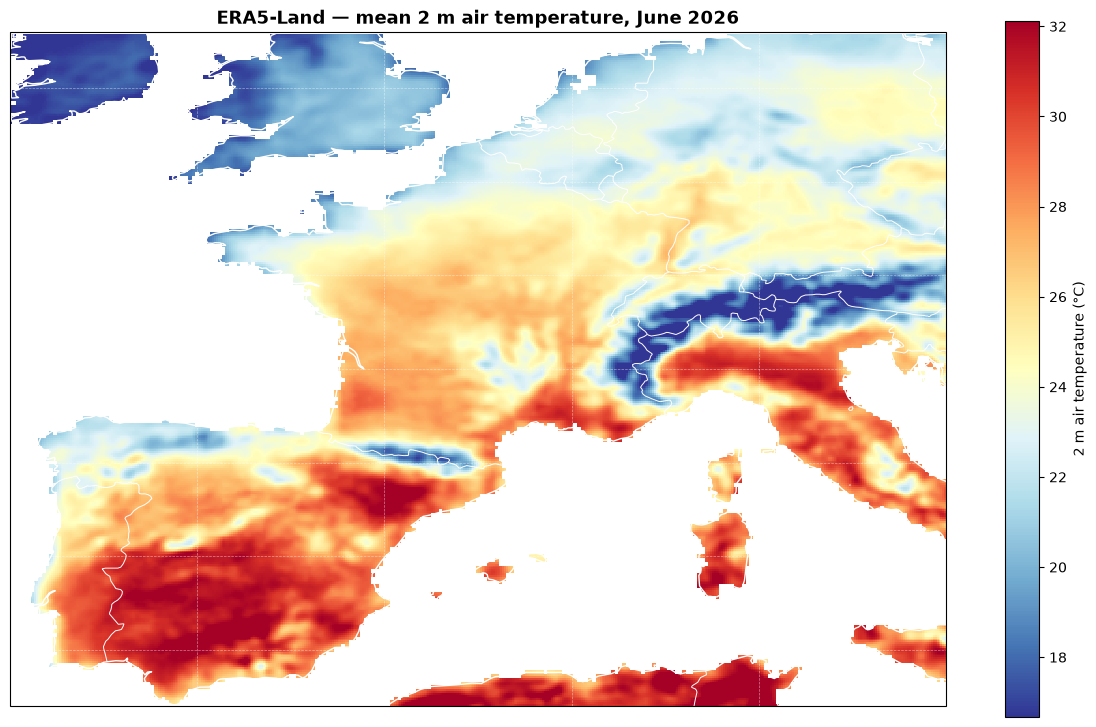

In [ ]:
# Plot the June mean 2 m air temperature, converting from Kelvin to Celsius
era5_mean_t2m = era5_mean.data["2t"].isel(time=0) - 273.15

plot_temperature_map(
    era5_mean_t2m,
    f"ERA5-Land : mean 2 m air temperature, June {YEAR}",
    "2 m air temperature (°C)",
    cmap="RdYlBu_r",
)

## DEFAIR Alignment: one analysis ready cube

The three June mean fields are now on the identical common grid (EPSG:4326, 0.05°,
lat 36–54 / lon −10–15, 500 × 360), verified to match coordinate-for-coordinate. `AlignmentPlugin`
merges them into a single dataset: it resolves the time axis (all three share the same monthly
bin) and prefixes the variable names so the two features and the label coexist without collision.
Because the grids are already identical, no spatial resampling actually happens here, the step is
a clean merge, and the result is the analysis-ready cube that an AI model will consume.

In [40]:
from defair_ops.transformations.alignment import AlignmentPlugin

# Merge the three June-mean fields into one cube. MSG is the base; EDLST and ERA5
# are aligned onto it. Grids are already identical, so this is effectively a merge.
with AlignmentPlugin() as alignment:
    aligned_cube = alignment.transform(
        msg_mean,
        target=TARGET_CRS,
        target_resolution=TARGET_RESOLUTION,
        datasets=[edlst_mean, era5_mean],
        spatial_method="bilinear",
        temporal_method="nearest",
        time_bounds="base",
        conflict_resolution="prefix",
    )

print("Aligned cube:")
print(f"  Dimensions: {dict(aligned_cube.data.sizes)}")
print(f"  Lat range: {float(aligned_cube.data.lat.min()):.2f} to {float(aligned_cube.data.lat.max()):.2f}")
print(f"  Lon range: {float(aligned_cube.data.lon.min()):.2f} to {float(aligned_cube.data.lon.max()):.2f}")
print(f"  Variables ({len(aligned_cube.data.data_vars)}):")
for var in aligned_cube.data.data_vars:
    print(f"    - {var}")

Aligned cube:
  Dimensions: {'time': 1, 'lon': 500, 'lat': 360}
  Lat range: 36.02 to 53.98
  Lon range: -9.97 to 14.98
  Variables (3):
    - msg_seviri_native_format_ir_10.8
    - metop_polar-orbiting_s_LST
    - era5_2t


2026-07-13 12:12:58 | INFO     | [3468ac99] defair_ops.transformations.alignment.alignment_plugin:_validate_transform_inputs:1487 - Starting alignment to target=EPSG:4326
2026-07-13 12:12:58 | INFO     | [3468ac99] defair_ops.transformations.alignment.alignment_plugin:transform:1147 - Aligning 3 dataset(s)
2026-07-13 12:12:58 | INFO     | [3468ac99] defair_ops.transformations.alignment.alignment_plugin:transform:1167 - Target time grid: 1 timestamps
2026-07-13 12:12:58 | INFO     | [3468ac99] defair_ops.transformations.alignment.alignment_plugin:_calculate_common_bounds:714 - Common bounds (union) for 3 datasets: (-10.0, 36.0, 15.000000000000002, 54.0)
2026-07-13 12:12:58 | INFO     | [3468ac99] defair_ops.transformations.alignment.alignment_plugin:transform:1182 - Using common bounds for grid alignment: lon=[-10.0000, 15.0000], lat=[36.0000, 54.0000]
2026-07-13 12:12:58 | INFO     | [3468ac99] defair_ops.transformations.reprojection.reprojection:transform:273 - Starting reprojection t

### Verification plot: the three aligned sources side by side

The two features (MSG brightness temperature, EDLST surface temperature) and the label (ERA5-Land
air temperature) on the shared grid, all in °C. Reading left to right, the surface-to-air offset
is visible: EDLST is the warmest (corrected surface), ERA5-Land the coolest (air), MSG in between
(uncorrected brightness). That systematic offset is exactly the relationship the model will learn.

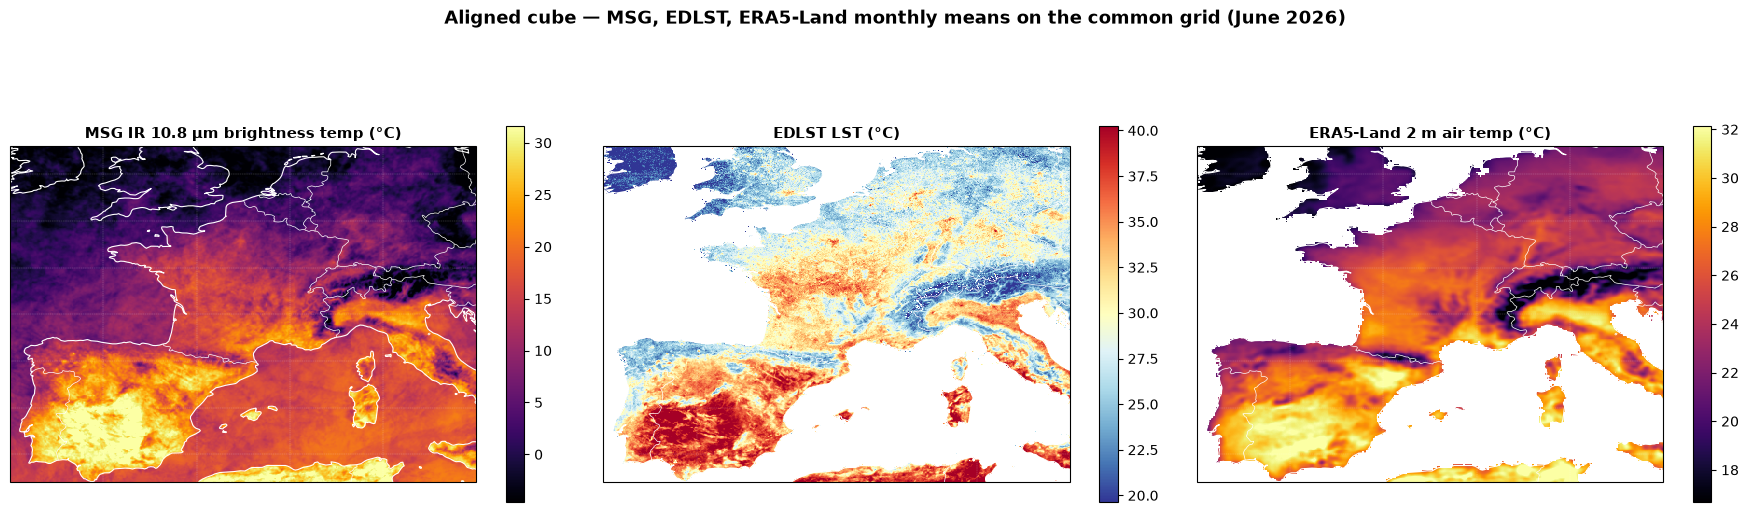

In [ ]:
# Reference the three variables by their prefixed names in the aligned cube
cube = aligned_cube.data
msg_var = "msg_seviri_native_format_ir_10.8"
edlst_var = "metop_polar-orbiting_s_LST"
era5_var = "era5_2t"

# Bring all three to Celsius on the common grid (EDLST is already in °C)
msg_data = cube[msg_var].isel(time=0, drop=True).compute() - 273.15
edlst_data = cube[edlst_var].isel(time=0, drop=True).compute()
era5_data = cube[era5_var].isel(time=0, drop=True).compute() - 273.15

panels = [
    (msg_data, "MSG IR 10.8 µm brightness temp (°C)", "inferno"),
    (edlst_data, "EDLST LST (°C)", "RdYlBu_r"),
    (era5_data, "ERA5-Land 2 m air temp (°C)", "inferno"),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 6), subplot_kw={"projection": ccrs.PlateCarree()})

for ax, (data, title, cmap) in zip(axes, panels):
    vmin = float(np.nanpercentile(data.values, 2))
    vmax = float(np.nanpercentile(data.values, 98))
    ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())
    im = ax.pcolormesh(
        data["lon"].values, data["lat"].values, data.values,
        cmap=cmap, vmin=vmin, vmax=vmax,
        transform=ccrs.PlateCarree(), shading="auto",
    )
    ax.coastlines(resolution="50m", linewidth=0.8, color="white")
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor="white")
    ax.gridlines(draw_labels=False, linewidth=0.3, alpha=0.4, linestyle="--", color="white")
    ax.set_title(title, fontsize=11, fontweight="bold")
    plt.colorbar(im, ax=ax, shrink=0.7)

plt.suptitle(f"Aligned cube : MSG, EDLST, ERA5-Land monthly means on the common grid (June {YEAR})",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "aligned_cube_verification.png"), dpi=150, bbox_inches="tight")
plt.show()

## Machine learning: statistical mapping to air temperature

The model performs one thing only: a direct statistical mapping from two satellite features to
the ERA5-Land air temperature label, per pixel, on the June-mean cube. It does not solve a
surface energy balance or model the boundary layer, all of that physics is implicitly absorbed
into the parameters learned from the data.

[MSG mean BT, EDLST mean LST]  ──(model)──▶  estimated mean air temperature

**Anti-circularity, restated in practice:** the feature matrix `X` is built only from MSG and
EDLST; ERA5-Land contributes only the target `y`. ERA5-Land is land-only, so ocean pixels are
NaN in the label and are dropped before training, this defines the terrestrial domain of the
problem.

### Assemble the pixel table

Flatten the 360×500 grid into one row per pixel, keep only pixels where all three variables are
valid (i.e. land pixels with a valid satellite retrieval that day), and add the pixel's lat/lon
so a spatial split can be built afterwards.


In [43]:
# Flatten the aligned cube into one row per pixel: two features (x1, x2) and one label (y)
lat_2d, lon_2d = np.meshgrid(aligned_cube.data["lat"].values, aligned_cube.data["lon"].values, indexing="ij")

pixel_table = xr.Dataset(
    {
        "msg_bt": aligned_cube.data[msg_var].isel(time=0, drop=True) - 273.15,   # K -> degC
        "edlst_lst": aligned_cube.data[edlst_var].isel(time=0, drop=True),        # already degC
        "era5_t2m": aligned_cube.data[era5_var].isel(time=0, drop=True) - 273.15, # K -> degC
    }
).to_dataframe().reset_index()

# Keep only pixels where all three variables are valid (this is the land domain,
# since ERA5-Land has no data over sea)
pixel_table = pixel_table.dropna(subset=["msg_bt", "edlst_lst", "era5_t2m"])

print(f"Total grid pixels:  {aligned_cube.data.sizes['lat'] * aligned_cube.data.sizes['lon']:,}")
print(f"Valid land pixels:  {len(pixel_table):,}")
print(pixel_table[["msg_bt", "edlst_lst", "era5_t2m"]].describe())

Total grid pixels:  180,000
Valid land pixels:  102,193
              msg_bt      edlst_lst       era5_t2m
count  102193.000000  102193.000000  102193.000000
mean       12.123161      29.780878      24.970405
std        10.742148       5.074660       3.981482
min        -9.941528      -1.126546       9.401184
25%         2.642273      26.339071      22.583288
50%        11.594818      29.395676      24.690649
75%        20.821686      33.236740      27.763411
max        39.194824      47.429504      34.856620


### Spatial block train/validation split

Neighbouring pixels are strongly autocorrelated, so a random pixel-wise split would leak
information between train and validation and inflate the metrics artificially. Instead, the study
area is divided into large longitude strips, and whole strips are assigned to either train or
validation, roughly 75% train, 25% validation.

In [45]:
# Spatial block split: divide the area into longitude strips, assign whole strips
# to train or validation (not individual pixels), avoiding spatial leakage.
N_STRIPS = 10
VALIDATION_FRACTION = 0.25

strip_edges = np.linspace(LON_MIN, LON_MAX, N_STRIPS + 1)
pixel_table["strip"] = np.digitize(pixel_table["lon"], strip_edges[1:-1])

# Hold out every 4th strip for validation (regular spacing avoids bias toward one region)
n_val_strips = max(1, round(N_STRIPS * VALIDATION_FRACTION))
val_strips = np.linspace(0, N_STRIPS - 1, n_val_strips, dtype=int)

pixel_table["split"] = np.where(pixel_table["strip"].isin(val_strips), "validation", "train")

train_df = pixel_table[pixel_table["split"] == "train"]
val_df = pixel_table[pixel_table["split"] == "validation"]

print(f"Train pixels:      {len(train_df):,} ({100 * len(train_df) / len(pixel_table):.1f}%)")
print(f"Validation pixels: {len(val_df):,} ({100 * len(val_df) / len(pixel_table):.1f}%)")

Train pixels:      85,092 (83.3%)
Validation pixels: 17,101 (16.7%)


### Random Forest regression

A Random Forest is a simple non-linear model: it averages many decision trees, each trained on a
random subset of the data. Unlike the linear baseline it can capture a surface to air relationship
that varies across the region (coast vs. inland, different soil moisture regimes) without being
told the functional form. It is used here with modest settings:  the goal is a working, honest
estimate, not a heavily tuned model. Just demonstration purposes

In [55]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

feature_cols = ["msg_bt", "edlst_lst"]
label_col = "era5_t2m"

X_train, y_train = train_df[feature_cols], train_df[label_col]
X_val, y_val = val_df[feature_cols], val_df[label_col]


def evaluate(model, X, y_true, label):
    """Print RMSE, MAE, R2 and mean bias for a model's predictions."""
    y_pred = model.predict(X)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    bias = (y_pred - y_true).mean()

    print(f"{label}")
    print(f"  RMSE: {rmse:.2f} degC")
    print(f"  MAE:  {mae:.2f} degC")
    print(f"  R2:   {r2:.3f}")
    print(f"  Bias: {bias:+.2f} degC")
    return y_pred


# n_estimators: number of trees; random_state fixes the result so it is reproducible
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

rf_val_pred = evaluate(rf_model, X_val, y_val, "Random Forest — validation")

Random Forest — validation
  RMSE: 2.32 degC
  MAE:  1.73 degC
  R2:   0.625
  Bias: -1.02 degC


## Results

### Estimated air temperature map

The trained Random Forest is applied to every valid land pixel to produce the June-mean 2 m air
temperature estimated from the two satellite features alone. The flat per-pixel predictions are
placed back onto the 360×500 grid for mapping.

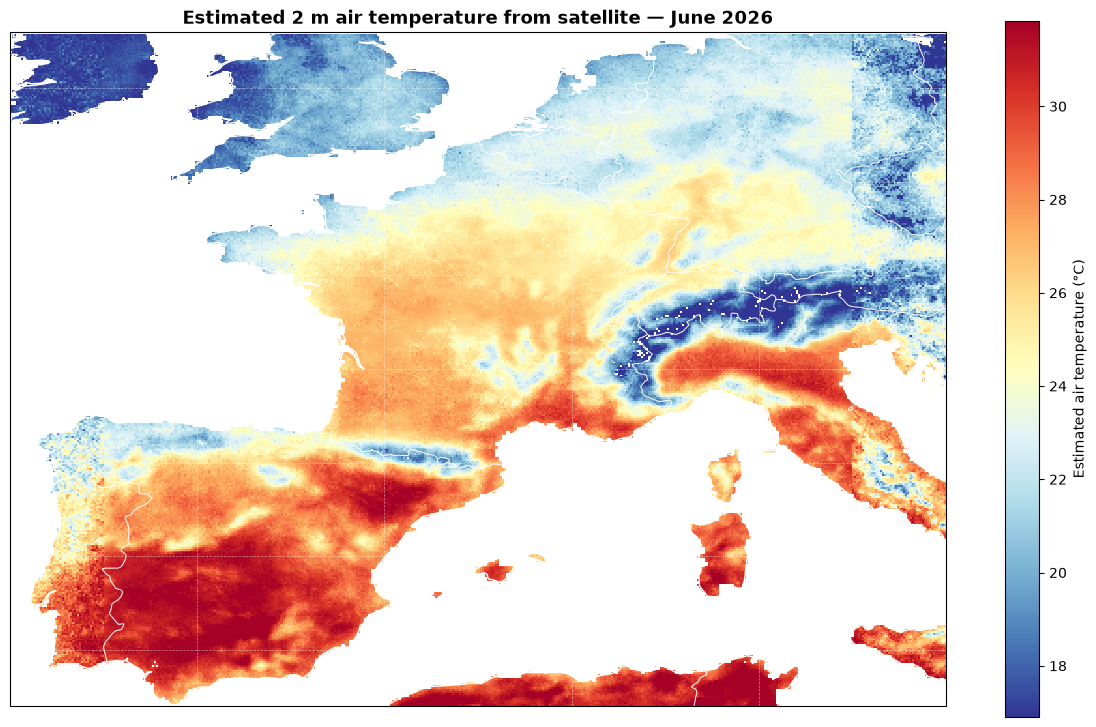

In [60]:
# Predict on all valid land pixels, then place the predictions back on the 2D grid
pixel_table = pixel_table.copy()
pixel_table["t2m_predicted"] = rf_model.predict(pixel_table[feature_cols])

# Empty grid (NaN everywhere), then fill it at the (lat, lon) of each predicted pixel
grid_shape = (aligned_cube.data.sizes["lat"], aligned_cube.data.sizes["lon"])
predicted_grid = xr.DataArray(
    np.full(grid_shape, np.nan),
    dims=["lat", "lon"],
    coords={"lat": aligned_cube.data["lat"], "lon": aligned_cube.data["lon"]},
)
predicted_grid.loc[
    dict(lat=xr.DataArray(pixel_table["lat"].values, dims="points"),
         lon=xr.DataArray(pixel_table["lon"].values, dims="points"))
] = pixel_table["t2m_predicted"].values

plot_temperature_map(
    predicted_grid,
    f"Estimated 2 m air temperature from satellite — June {YEAR}",
    "Estimated air temperature (°C)",
    cmap="RdYlBu_r",
)

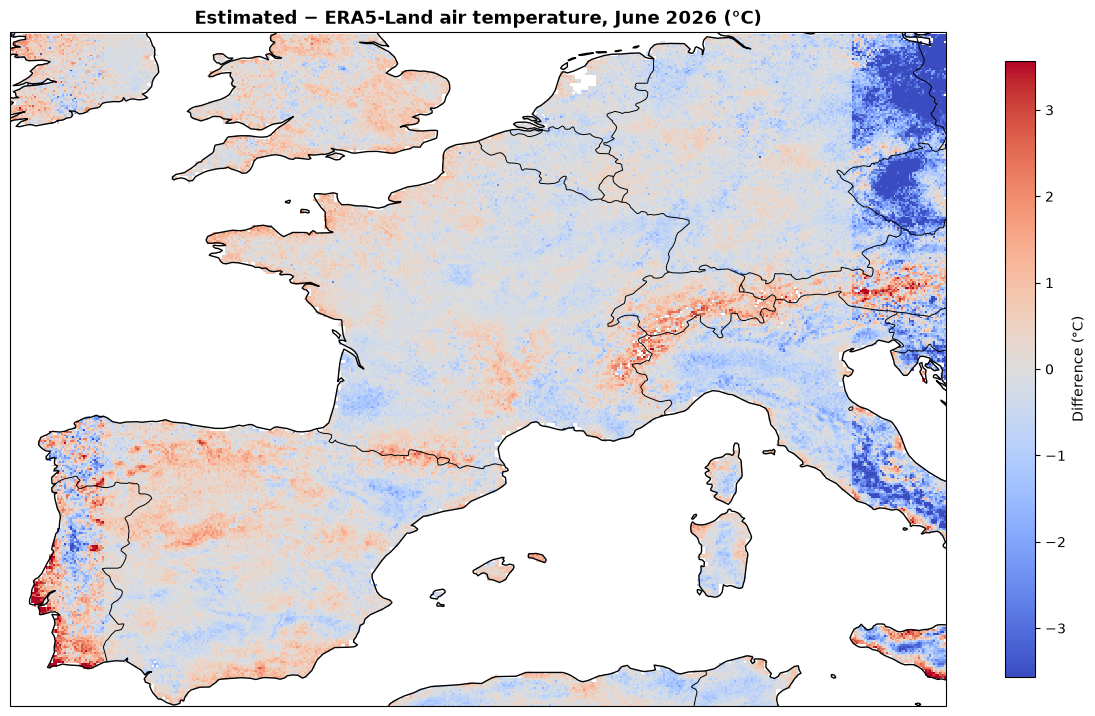

Difference statistics (degC):
  Mean:   -0.17
  Std:    1.07
  Min/Max: -11.69 / +7.24


In [61]:
# Difference between the satellite estimate and the ERA5-Land reference, on the grid
difference_grid = predicted_grid - (aligned_cube.data[era5_var].isel(time=0, drop=True) - 273.15)

fig = plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.PlateCarree())
ax.set_extent([LON_MIN, LON_MAX, LAT_MIN, LAT_MAX], crs=ccrs.PlateCarree())

vmax = float(np.nanpercentile(np.abs(difference_grid.values), 98))
im = ax.pcolormesh(
    difference_grid["lon"].values, difference_grid["lat"].values, difference_grid.values,
    cmap="coolwarm", vmin=-vmax, vmax=vmax,
    transform=ccrs.PlateCarree(), shading="auto",
)
ax.coastlines(resolution="50m", linewidth=1.0, color="black")
ax.add_feature(cfeature.BORDERS, linewidth=0.7, edgecolor="black")
ax.set_title(f"Estimated − ERA5-Land air temperature, June {YEAR} (°C)", fontsize=13, fontweight="bold")
plt.colorbar(im, ax=ax, label="Difference (°C)", shrink=0.8)
plt.tight_layout()
plt.show()

print("Difference statistics (degC):")
diff_valid = difference_grid.values[~np.isnan(difference_grid.values)]
print(f"  Mean:   {diff_valid.mean():+.2f}")
print(f"  Std:    {diff_valid.std():.2f}")
print(f"  Min/Max: {diff_valid.min():+.2f} / {diff_valid.max():+.2f}")

## Summary

### DEFAIR in this project

DEFAIR was used for the entire data-preparation pipeline: reading, filtering, cropping,
reprojecting, temporally aggregating and merging the three sources into a single analysis-ready
cube. It sat between raw data access (HDA downloads with `requests`) and the machine-learning
step (`scikit-learn`), covering everything in between.

## References

- Benali et al. (2012), *Remote Sensing of Environment* 124, 108–121.
- Janatian et al. (2017), *International Journal of Climatology*, doi:10.1002/joc.4766.
- Wan & Dozier (1996), *IEEE TGRS* 34(4), 892–905.
- Gao et al. (2013), *International Journal of Remote Sensing* 34(12), 4182–4199.
